In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision  #official pytorch library and for specially computer vision
from torchvision.datasets import CIFAR10

In [4]:
#Datasets and Dataloaders
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = CIFAR10(root="./data", train=False, download=True, transform=transform)

In [5]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

### Build the CNN

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # kernel size = 2, stride = 2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) ,

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flattening
        x = self.fc_layers(x)

        return x

In [7]:
model = CNN()

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

### Training the CNN

In [9]:
val_losses = []

best_val_loss = float("inf")

epochs = 10

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        
        output = model.forward(images) # FP
        loss = criterion(output, labels) # loss fnx
        loss.backward() # BP
        optimizer.step() # update params

        epoch_training_loss += loss.item()

    #Validation 
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): #no gradients compute
        for images, labels in testloader:
            outputs = model(images) 
            loss = criterion(outputs, labels)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(testloader)
    val_losses.append(epoch_val_loss)

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") #.pt or .pth




epoch=1/10 & loss=1.3499003891139993
epoch=2/10 & loss=0.927165578774479
epoch=3/10 & loss=0.752573383281298
epoch=4/10 & loss=0.6246220576564979
epoch=5/10 & loss=0.5244067663808003
epoch=6/10 & loss=0.43228921082699695
epoch=7/10 & loss=0.3463470128738819
epoch=8/10 & loss=0.27036357582415765
epoch=9/10 & loss=0.20924524080646617
epoch=10/10 & loss=0.16674001122612858


In [10]:
# Evaludate our CNN

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model.forward(images)
        _, predicted  = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels / total_labels * 100}")

accuracy = 75.46000000000001


In [11]:
model = CNN()

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [12]:
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

image, label = testset[0]

with torch.no_grad():
    output = model(image.unsqueeze(0))
    pred = output.argmax(1).item()

print("Actual:", classes[label])
print("Predicted:", classes[pred])

Actual: cat
Predicted: cat


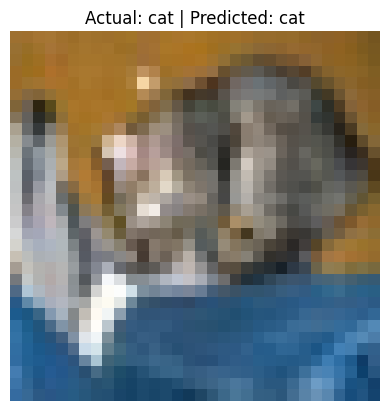

In [13]:
import matplotlib.pyplot as plt

image, label = testset[0]

with torch.no_grad():
    pred = model(image.unsqueeze(0)).argmax(1).item()

img = image / 2 + 0.5
img = img.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Actual: {classes[label]} | Predicted: {classes[pred]}")
plt.axis('off')
plt.show()